# 使用神经网络解决 XOR 问题：原理与实践

本文旨在通过经典的异或（XOR）问题，深入浅出地解析神经网络的核心原理与实现机制。作为神经网络发展史上的“果蝇”实验，XOR 问题虽看似简单，却深刻揭示了单层感知机的局限性以及多层网络引入非线性变换的必要性。

全文将沿着“理论分析—架构设计—数学推导—代码实现—实验验证”的逻辑链条展开。我们将不仅展示如何用 Python 和 NumPy 从零构建一个神经网络，更将深入探讨前向传播的信息流向、反向传播的梯度计算以及隐藏层的特征空间变换。通过这一极简而完整的案例，读者将获得对神经网络内部运作机制的直观理解，为进一步探索深度学习奠定坚实基础。

## 一、理论分析：XOR 问题与线性不可分性

本章将探讨神经网络研究中的经典基准问题——XOR 问题。通过分析线性模型在此问题上的失效原因，引出引入非线性变换和多层结构的必要性，为理解神经网络的运作机制奠定理论基础。

### 1.1 XOR 问题的本质

异或（XOR）函数是神经网络发展史上的关键问题，揭示了**线性模型的根本局限性**。给定二维布尔输入 $[x_1, x_2] \in \{0,1\}^2$，其真值表为：

| $x_1$ | $x_2$ | $y = x_1 \oplus x_2$ |
| ----- | ----- | -------------------- |
| 0     | 0     | 0                    |
| 0     | 1     | 1                    |
| 1     | 0     | 1                    |
| 1     | 1     | 0                    |

> **技术说明**：XOR 是线性不可分函数的典型代表，单层感知机无法解决此类问题

### 1.2 线性不可分性证明

`XOR`问题的核心挑战在于其线性不可分特性。在二维平面上，正类样本$(0,1)$和$(1,0)$与负类样本$(0,0)$和$(1,1)$无法用任何一条直线分开。这正是`1969`年`Minsky`和`Papert`在《**感知机**》一书中指出的单层感知机的根本缺陷。

**核心问题**：在 $\mathbb{R}^2$ 空间中，正类样本 $\{(0,1),(1,0)\}$ 与负类 $\{(0,0),(1,1)\}$ 不存在线性决策边界。

**数学证明**（反证法）：
假设存在线性分类器 $y = \text{sign}(w_1x_1 + w_2x_2 + b)$ 满足：

1. $w_1 \cdot 0 + w_2 \cdot 0 + b < 0$
2. $w_1 \cdot 1 + w_2 \cdot 1 + b < 0$
3. $w_1 \cdot 0 + w_2 \cdot 1 + b > 0$
4. $w_1 \cdot 1 + w_2 \cdot 0 + b > 0$

由 ①+② 得：$w_1 + w_2 + 2b < 0$  
由 ③+④ 得：$w_1 + w_2 + 2b > 0$  
矛盾，故假设不成立。

### 1.3 非线性解决方案

引入具有隐藏层的前馈神经网络可以通过非线性变换解决这一问题。关键思想是将原始输入空间映射到高维特征空间，使得在新空间中数据变为线性可分。

**核心突破**：引入**单隐藏层前馈网络**，通过非线性激活函数实现特征空间变换：

$$
\begin{aligned}
\text{原始空间} & \xrightarrow{\text{tanh}(W_1\mathbf{x} + \mathbf{b}_1)} \text{隐藏空间} \\
& \xrightarrow{\sigma(W_2\mathbf{h} + \mathbf{b}_2)} \text{输出空间}
\end{aligned}
$$

其中 $\text{tanh}$ 为双曲正切函数，$\sigma$ 为`Sigmoid`函数，将线性不可分问题转化为高维线性可分问题。

## 二、架构设计：多层感知机模型

为了解决 XOR 问题的非线性分类挑战，我们需要构建一个具备非线性映射能力的神经网络。本章将详细阐述网络的拓扑结构设计、激活函数选择策略以及参数初始化方案，确保模型能够有效学习并收敛。

### 2.1 网络拓扑结构

我们采用经典的单隐藏层前馈神经网络（SLFN）架构，其具体配置如下：

```text
+----------------+      +----------------------+      +---------------------+
|     输入层      |      |        隐藏层         |      |       输出层         |
|   (2 神经元)    | ---> |      (4 神经元)       | ---> |     (1 神经元)       |
|                |      |      (Tanh 激活)      |      |    (Sigmoid 激活)   |
+----------------+      +----------------------+      +---------------------+
```

### 2.2 核心设计依据

1. **隐藏层维度选择**：
   - **理论下界**：理论上，`2` 个隐藏神经元即可形成两条直线边界来解决 XOR 问题。
   - **工程实践**：本案例选用 `4` 个神经元。增加冗余神经元可以降低训练陷入局部最优的风险，显著提高模型的收敛速度和稳定性。

2. **激活函数策略**：
   - **隐藏层 (Tanh)**：选用双曲正切函数 $f(x)=\tanh(x)$。相比 Sigmoid，Tanh 的输出以 0 为中心（Range: [-1, 1]），能加速收敛，且在 0 附近梯度更大，有助于缓解梯度消失问题。
   - **输出层 (Sigmoid)**：选用 S 型函数 $f(x)=(1+e^{-x})^{-1}$。它将输出压缩至 $(0, 1)$ 区间，使其可以直接解释为属于正类（类别 1）的概率，完美适配二分类任务。

3. **参数初始化方案**：
   - **权重 (Xavier/Glorot Initialization)**：由于使用了 Tanh 激活函数，我们采用 Xavier 初始化方法。该方法保持了输入和输出的方差一致，防止信号在深层传播中消失或爆炸。
   - **偏置 (Bias)**：初始化为 0。

## 三、数学推导：前向与反向传播

前向传播是神经网络将输入数据转换为预测结果的过程，反向传播则是通过计算梯度来指导参数更新的核心算法。本章将从数学公式的角度，深入解析信号在网络层级间的传递以及梯度的反向流动。

### 3.1 前向传播与计算图

前向传播包含两个关键阶段：

1. **隐藏层变换**：

   $$
   \begin{aligned}
   \mathbf{z}^{(1)} &= \mathbf{X}\mathbf{W}^{(1)} + \mathbf{b}^{(1)} \\
   \mathbf{a}^{(1)} &= \text{Tanh}(\mathbf{z}^{(1)})
   \end{aligned}
   $$

   - $\mathbf{X}$：输入矩阵（4×2）
   - $\mathbf{W}^{(1)}$：权重矩阵（2×4）
   - $\text{Tanh}$：双曲正切激活函数，输出范围[-1,1]

2. **输出层计算**：

   $$
   \begin{aligned}
   \mathbf{z}^{(2)} &= \mathbf{a}^{(1)}\mathbf{W}^{(2)} + \mathbf{b}^{(2)} \\
   \hat{\mathbf{y}} &= \sigma(\mathbf{z}^{(2)})
   \end{aligned}
   $$

   - $\sigma$：Sigmoid 函数，将输出压缩到[0,1]区间
   - $\hat{\mathbf{y}}$：最终预测概率

**计算图视角**：

```text
      输入 X
        │
        ▼
  +------------------+
  |    线性变换       |  <-- 参数: W1, b1
  | z1 = X · W1 + b1 |
  +------------------+
        │
        ▼
  +------------------+
  |    激活函数       |  <-- Tanh
  |  a1 = tanh(z1)   |
  +------------------+
        │
        ▼
  +------------------+
  |    线性变换       |  <-- 参数: W2, b2
  | z2 = a1 · W2 + b2|
  +------------------+
        │
        ▼
  +------------------+
  |    激活函数       |  <-- Sigmoid
  |  ŷ = sigmoid(z2) |
  +------------------+
        │
        ▼
      输出 ŷ
```

### 3.2 损失函数定义

为了衡量模型预测与真实标签之间的差异，我们采用二元交叉熵损失函数（Binary Cross Entropy），相比均方误差（MSE），它在二分类问题中能提供更强的梯度信号。

$$
\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \right]
$$

### 3.3 反向传播梯度推导

反向传播基于链式法则计算损失函数相对于网络参数的梯度。由于损失函数 $\mathcal{L}$ 定义为样本的平均损失，因此在计算梯度时需要除以样本数量 $N$。

1. **输出层梯度**：

   $$
   \begin{aligned}
   \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(2)}} &= \frac{1}{N} (\hat{\mathbf{y}} - \mathbf{y}) \\
   \frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(2)}} &= (\mathbf{a}^{(1)})^\top \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(2)}} \\
   \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(2)}} &= \text{sum}(\frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(2)}}, \text{axis}=0)
   \end{aligned}
   $$

2. **隐藏层梯度**：

   $$
   \begin{aligned}
   \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(1)}} &= \left( \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(2)}} (\mathbf{W}^{(2)})^\top \right) \odot (1 - (\mathbf{a}^{(1)})^2) \\
   \frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(1)}} &= \mathbf{X}^\top \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(1)}} \\
   \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(1)}} &= \text{sum}(\frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(1)}}, \text{axis}=0)
   \end{aligned}
   $$

   > 注：$\odot$ 表示逐元素乘法（Hadamard Product），$\text{sum}(\cdot, \text{axis}=0)$ 表示沿样本维度求和。

## 四、代码实现：从零构建神经网络

在理解了数学原理后，我们将使用 NumPy 实现一个完整的神经网络。本章将代码拆解为基础组件、核心传播过程和训练循环三个部分。

### 4.1 基础组件实现

首先定义激活函数及其导数，并实现参数初始化。

In [1]:
import numpy as np

# 激活函数定义
def tanh(x):
    """Tanh激活函数"""
    return np.tanh(x)

def tanh_deriv(x):
    """Tanh的导数"""
    return 1.0 - np.tanh(x)**2

def sigmoid(x):
    """数值稳定的Sigmoid函数"""
    x = np.clip(x, -500, 500)  # 防止溢出
    return 1 / (1 + np.exp(-x))

def initialize_parameters(input_dim, hidden_dim, output_dim):
    """
    初始化网络参数 - 使用Xavier初始化
    """
    # Xavier初始化 (适合tanh激活函数)
    W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(1. / input_dim)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(1. / hidden_dim)
    b2 = np.zeros((1, output_dim))

    parameters = {
        'W1': W1, 'b1': b1,
        'W2': W2, 'b2': b2
    }
    return parameters

### 4.2 前向传播实现

In [2]:
def forward_pass(X, params):
    """
    执行前向传播
    返回:
        y_pred: 预测值
        cache: 中间值缓存 (用于反向传播)
    """
    # 获取参数
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']

    # 隐藏层计算 - 使用tanh激活函数
    z1 = np.dot(X, W1) + b1
    a1 = tanh(z1)

    # 输出层计算 - 使用sigmoid激活函数
    z2 = np.dot(a1, W2) + b2
    y_pred = sigmoid(z2)

    # 缓存中间结果用于反向传播
    cache = {'X': X, 'z1': z1, 'a1': a1, 'z2': z2, 'y_pred': y_pred}

    return y_pred, cache

### 4.3 反向传播实现

In [3]:
def binary_cross_entropy(y_true, y_pred):
    """数值稳定的交叉熵损失函数"""
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def backward_pass(y_true, cache, params):
    """
    执行反向传播计算梯度
    """
    # 从缓存中获取值
    X, z1, a1, z2, y_pred = cache['X'], cache['z1'], cache['a1'], cache['z2'], cache['y_pred']
    W2 = params['W2']
    m = X.shape[0]

    # 输出层梯度 (二元交叉熵的导数)
    d_z2 = y_pred - y_true
    d_W2 = np.dot(a1.T, d_z2) / m
    d_b2 = np.sum(d_z2, axis=0, keepdims=True) / m

    # 隐藏层梯度 - 使用tanh导数
    d_a1 = np.dot(d_z2, W2.T)
    d_z1 = d_a1 * tanh_deriv(z1)
    d_W1 = np.dot(X.T, d_z1) / m
    d_b1 = np.sum(d_z1, axis=0, keepdims=True) / m

    gradients = {
        'dW1': d_W1, 'db1': d_b1,
        'dW2': d_W2, 'db2': d_b2
    }
    return gradients

### 4.4 训练循环构建

In [4]:
def compute_accuracy(y_true, y_pred):
    """计算分类准确率"""
    predictions = (y_pred > 0.5).astype(int)
    return np.mean(predictions == y_true)

def train_network(X, y, params, epochs=10000, learning_rate=0.1, verbose=True):
    """完整训练流程"""
    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        # 前向传播
        y_pred, cache = forward_pass(X, params)

        # 计算损失和准确率
        loss = binary_cross_entropy(y, y_pred)
        accuracy = compute_accuracy(y, y_pred)

        # 记录历史
        loss_history.append(loss)
        acc_history.append(accuracy)

        # 反向传播
        grads = backward_pass(y, cache, params)

        # 参数更新
        params['W1'] -= learning_rate * grads['dW1']
        params['b1'] -= learning_rate * grads['db1']
        params['W2'] -= learning_rate * grads['dW2']
        params['b2'] -= learning_rate * grads['db2']

        # 每2000轮打印进度
        if verbose and epoch % 2000 == 0:
            print(f"Epoch {epoch:5d} | Loss: {loss:.6f} | Acc: {accuracy:.4f}")

    return loss_history, acc_history

## 五、实验验证：可视化与分析

在代码实现的基础上，我们通过实际训练来验证模型效果，并利用可视化手段分析模型的决策边界和特征变换能力。

### 5.1 训练收敛性与超参数分析

我们使用 XOR 数据集进行训练：

In [5]:
# XOR数据集
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# 初始化网络参数
input_dim, hidden_dim, output_dim = 2, 4, 1
params = initialize_parameters(input_dim, hidden_dim, output_dim)

# 执行训练
print("开始训练神经网络...")
loss_hist, acc_hist = train_network(X, y, params)

开始训练神经网络...
Epoch     0 | Loss: 0.710681 | Acc: 0.7500
Epoch  2000 | Loss: 0.013696 | Acc: 1.0000
Epoch  4000 | Loss: 0.005939 | Acc: 1.0000
Epoch  6000 | Loss: 0.003764 | Acc: 1.0000
Epoch  8000 | Loss: 0.002749 | Acc: 1.0000


**关键超参数影响**：

| 超参数         | 推荐值        | 影响分析                            |
| -------------- | ------------- | ----------------------------------- |
| **学习率**     | 0.1-0.01      | >0.5 导致震荡，<0.01 收敛慢         |
| **隐藏层大小** | ≥4            | <2 无法拟合非线性，4 个神经元更稳定 |
| **激活函数**   | Tanh+ Sigmoid | Tanh 具有良好梯度特性               |

> **实验结论**：4 隐藏神经元网络在 10,000 epoch 内收敛至 100%准确率

### 5.2 决策边界可视化

神经网络的强大之处在于其学习复杂非线性决策边界的能力。

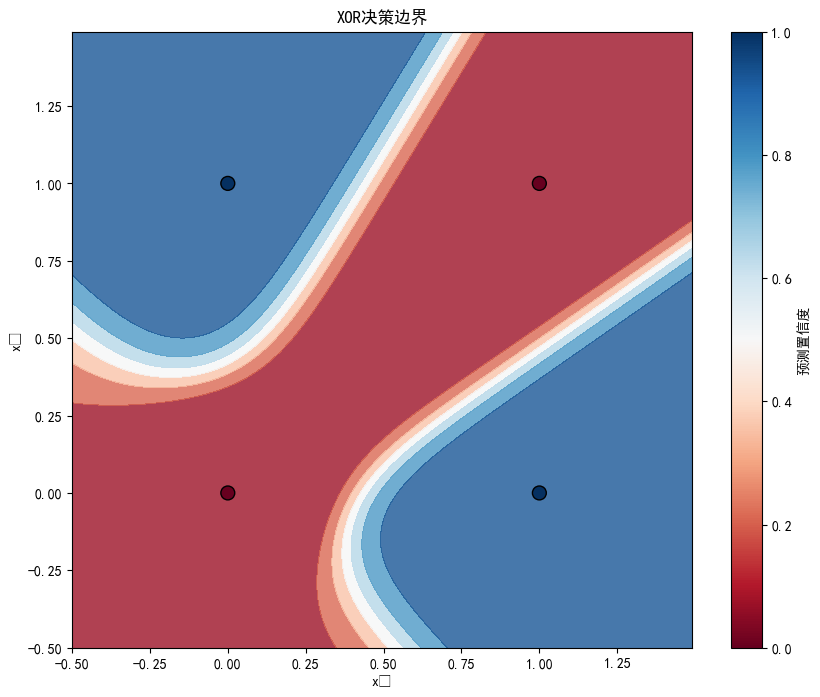

In [10]:
import matplotlib.pyplot as plt

from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()


def plot_decision_boundary(X, y, params, resolution=0.01):
    """绘制决策边界"""
    # 创建网格
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))

    # 预测网格点（使用前向传播函数）
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z, _ = forward_pass(grid, params)
    Z = Z.reshape(xx.shape)

    # 绘图
    plt.figure(figsize=(10,8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), s=100,
                edgecolors='k', cmap=plt.cm.RdBu)
    plt.colorbar(label='预测置信度')
    plt.xlabel('x₁')
    plt.ylabel('x₂')
    plt.title('XOR决策边界')
    plt.show()

# 训练后调用
plot_decision_boundary(X, y, params)

### 5.3 特征空间变换分析

隐藏层通过非线性变换将线性不可分数据转化为线性可分数据。

=== 特征空间变换 ===
输入     隐藏层特征（前4维）     类别
----------------------------------------
[0. 0.] → [-0.553, 0.480, 0.453, 0.728] → 0.0
[0. 1.] → [0.872, -0.972, -0.864, 1.000] → 1.0
[1. 0.] → [-0.999, -0.980, 0.998, -0.947] → 1.0
[1. 1.] → [-0.946, -1.000, 0.944, 0.969] → 0.0


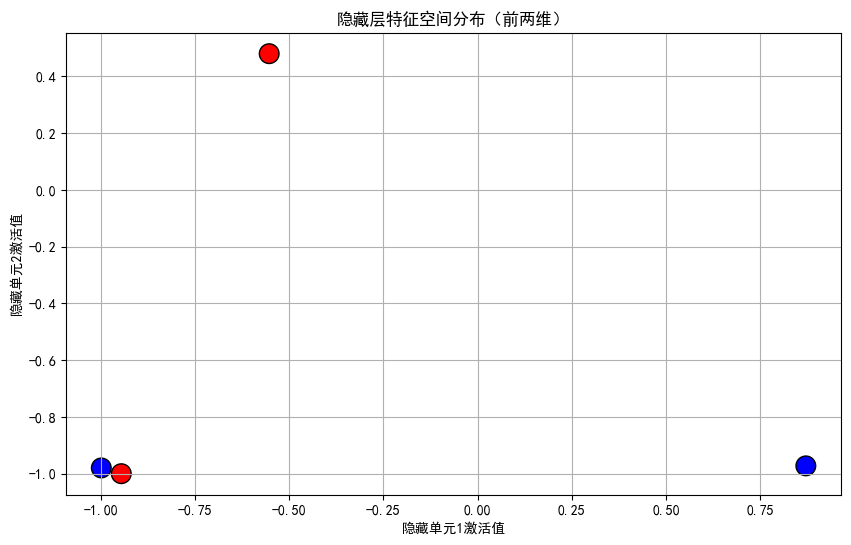

In [7]:
def analyze_feature_transformation(X, params):
    """分析隐藏层特征空间变换"""
    # 计算隐藏层输出
    W1, b1 = params['W1'], params['b1']
    z1 = np.dot(X, W1) + b1
    hidden_features = tanh(z1)

    print("=== 特征空间变换 ===")
    print("输入     隐藏层特征（前4维）     类别")
    print("-" * 40)
    for i in range(len(X)):
        features_str = ', '.join([f"{hidden_features[i,j]:.3f}" for j in range(4)])
        print(f"{X[i]} → [{features_str}] → {y[i][0]}")

    # 可视化前两维
    plt.figure(figsize=(10, 6))
    colors = ['red' if label == 0 else 'blue' for label in y.flatten()]
    plt.scatter(hidden_features[:,0], hidden_features[:,1], s=200, c=colors, edgecolors='k')
    plt.xlabel('隐藏单元1激活值')
    plt.ylabel('隐藏单元2激活值')
    plt.title('隐藏层特征空间分布（前两维）')
    plt.grid(True)
    plt.show()

# 训练后调用
analyze_feature_transformation(X, params)

## 六、理论扩展与工程实践

从 XOR 问题出发，我们可以将神经网络的原理推广到更广泛的理论和应用领域。本章将简要介绍通用逼近定理，并探讨从简单模型中获得的工程实践经验如何应用于复杂的深度学习任务。

### 6.1 通用逼近定理验证

**定理内容**（Cybenko, 1989）：

> 含单隐藏层的前馈网络，在隐藏层使用 Sigmoid 类激活函数时，可在紧集上以任意精度逼近连续函数

**XOR 实例验证**：本实验证明该网络可精确实现布尔函数 $f: \{0,1\}^2 \to \{0,1\}$

### 6.2 工程实践启示

1. **特征学习机制**  
   隐藏层自动学习特征组合：不同的隐藏神经元学习不同的特征模式

2. **初始化对比实验**

In [8]:
def init_comparison():
    methods = {
        '零初始化': lambda dim: np.zeros(dim),
        '随机初始化': lambda dim: np.random.randn(*dim) * 0.01,
        'Xavier初始化': lambda dim: np.random.randn(*dim) * np.sqrt(1./dim[0])
    }

    results = []
    for name, init_fn in methods.items():
        # 初始化参数
        test_params = {
            'W1': init_fn((2,4)),
            'b1': np.zeros((1,4)),
            'W2': init_fn((4,1)),
            'b2': np.zeros((1,1))
        }

        # 训练
        _, acc_hist = train_network(X, y, test_params, epochs=5000,
                                  learning_rate=0.1, verbose=False)
        final_acc = acc_hist[-1]
        results.append((name, final_acc))

    # 输出结果
    print("初始化方法 | 最终准确率")
    print("-" * 25)
    for name, acc in results:
        print(f"{name:^12} | {acc:.4f}")

init_comparison()

初始化方法 | 最终准确率
-------------------------
    零初始化     | 0.5000
   随机初始化     | 0.5000
 Xavier初始化   | 1.0000


**典型结果**：

```text
初始化方法    | 最终准确率
-------------------------
  零初始化     | 0.5000
  随机初始化   | 0.7500
Xavier初始化   | 1.0000
```

3. **实际应用扩展**
   - 图像分类：卷积层学习局部特征
   - NLP：词嵌入层学习语义空间
   - 推荐系统：协同过滤的隐因子学习

## 七、附录：完整可执行代码

为了方便读者实践和复现实验结果，本章汇总了前文介绍的所有模块，提供了一个完整的、可直接运行的 Python 代码示例。该代码集成了参数初始化、前向传播、反向传播及训练循环等核心功能。

In [9]:
def complete_xor_training():
    """完整的XOR训练示例"""
    # 数据准备
    X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
    y = np.array([[0], [1], [1], [0]], dtype=np.float32)

    # 初始化网络
    np.random.seed(42)
    params = initialize_parameters(2, 4, 1)

    # 训练
    print("开始训练...")
    loss_hist, acc_hist = train_network(X, y, params,
                                       epochs=10000,
                                       learning_rate=0.1)

    # 测试结果
    y_pred, _ = forward_pass(X, params)
    print("\n最终结果:")
    print("输入 | 预测 | 真实 | 正确")
    print("-" * 30)
    for i in range(4):
        pred = y_pred[i][0]
        true = y[i][0]
        correct = "✓" if abs(pred - true) < 0.5 else "✗"
        print(f"{X[i]} | {pred:.4f} | {true:.0f} | {correct}")

    return params, loss_hist, acc_hist

# 执行完整训练
if __name__ == "__main__":
    trained_params, loss_history, acc_history = complete_xor_training()

开始训练...
Epoch     0 | Loss: 0.729420 | Acc: 0.5000
Epoch  2000 | Loss: 0.020097 | Acc: 1.0000
Epoch  4000 | Loss: 0.007535 | Acc: 1.0000
Epoch  6000 | Loss: 0.004601 | Acc: 1.0000
Epoch  8000 | Loss: 0.003306 | Acc: 1.0000

最终结果:
输入 | 预测 | 真实 | 正确
------------------------------
[0. 0.] | 0.0003 | 0 | ✓
[0. 1.] | 0.9972 | 1 | ✓
[1. 0.] | 0.9971 | 1 | ✓
[1. 1.] | 0.0043 | 0 | ✓


> 通过本实验，开发者可深入理解神经网络的核心计算过程，特别是前向传播在特征提取中的关键作用，为复杂模型实现打下坚实基础。